In [2]:
# https://www.kaggle.com/competitions/playground-series-s6e8

# Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e8')

print("Path to competition files:", path)

Path to competition files: /home/rpsingh/.cache/kagglehub/competitions/playground-series-s6e8


In [4]:
train = pd.read_csv(f'{path}/train.csv')
test = pd.read_csv(f'{path}/test.csv')
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 296302 entries, 0 to 296301
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       296302 non-null  int64  
 1   age                      279164 non-null  float64
 2   daily_screen_time_hours  263514 non-null  float64
 3   social_media_hours       248905 non-null  float64
 4   gaming_hours             236882 non-null  float64
 5   work_study_hours         268525 non-null  float64
 6   sleep_hours              273847 non-null  float64
 7   notifications_per_day    262081 non-null  float64
 8   app_opens_per_day        270597 non-null  float64
 9   weekend_screen_time      245605 non-null  float64
 10  gender                   282090 non-null  str    
 11  stress_level             276676 non-null  str    
 12  academic_work_impact     270581 non-null  str    
dtypes: float64(9), int64(1), str(3)
memory usage: 32.6 MB


In [5]:
target_lebel = 'addicted_label'
train[target_lebel].value_counts(normalize=True)

addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64

##### Note:
Data is imbalanced.

## Missing values analysis

In [6]:
train[train.isna().any(axis=1)].shape

(422184, 14)

In [7]:
# Rows count vs number of null values.
train[train.isna().any(axis=1)].isna().sum(axis=1).value_counts()

1     180459
2     120697
3      67328
4      32557
5      13678
6       5157
7       1676
8        477
9        136
10        18
11         1
Name: count, dtype: int64

In [8]:
test[test.isna().any(axis=1)].isna().sum(axis=1).value_counts()

1     78974
2     52100
3     28838
4     13899
5      5926
6      2359
7       806
8       229
9        55
10       12
Name: count, dtype: int64

In [9]:
train[train.isna().sum(axis=1)>=4].groupby('addicted_label')['id'].count()

addicted_label
0    15542
1    38158
Name: id, dtype: int64

##### Note
1. Based on analysis test and train both have lot of null values rows. so we can't remove this. Les's fill these values

In [10]:
missing = train.isna().mean().sort_values(ascending=False)
missing[missing>0]

social_media_hours         0.193811
gaming_hours               0.183435
weekend_screen_time        0.162089
daily_screen_time_hours    0.138644
app_opens_per_day          0.116739
notifications_per_day      0.097754
stress_level               0.079766
work_study_hours           0.074516
sleep_hours                0.064336
academic_work_impact       0.063966
gender                     0.041995
age                        0.041843
dtype: float64

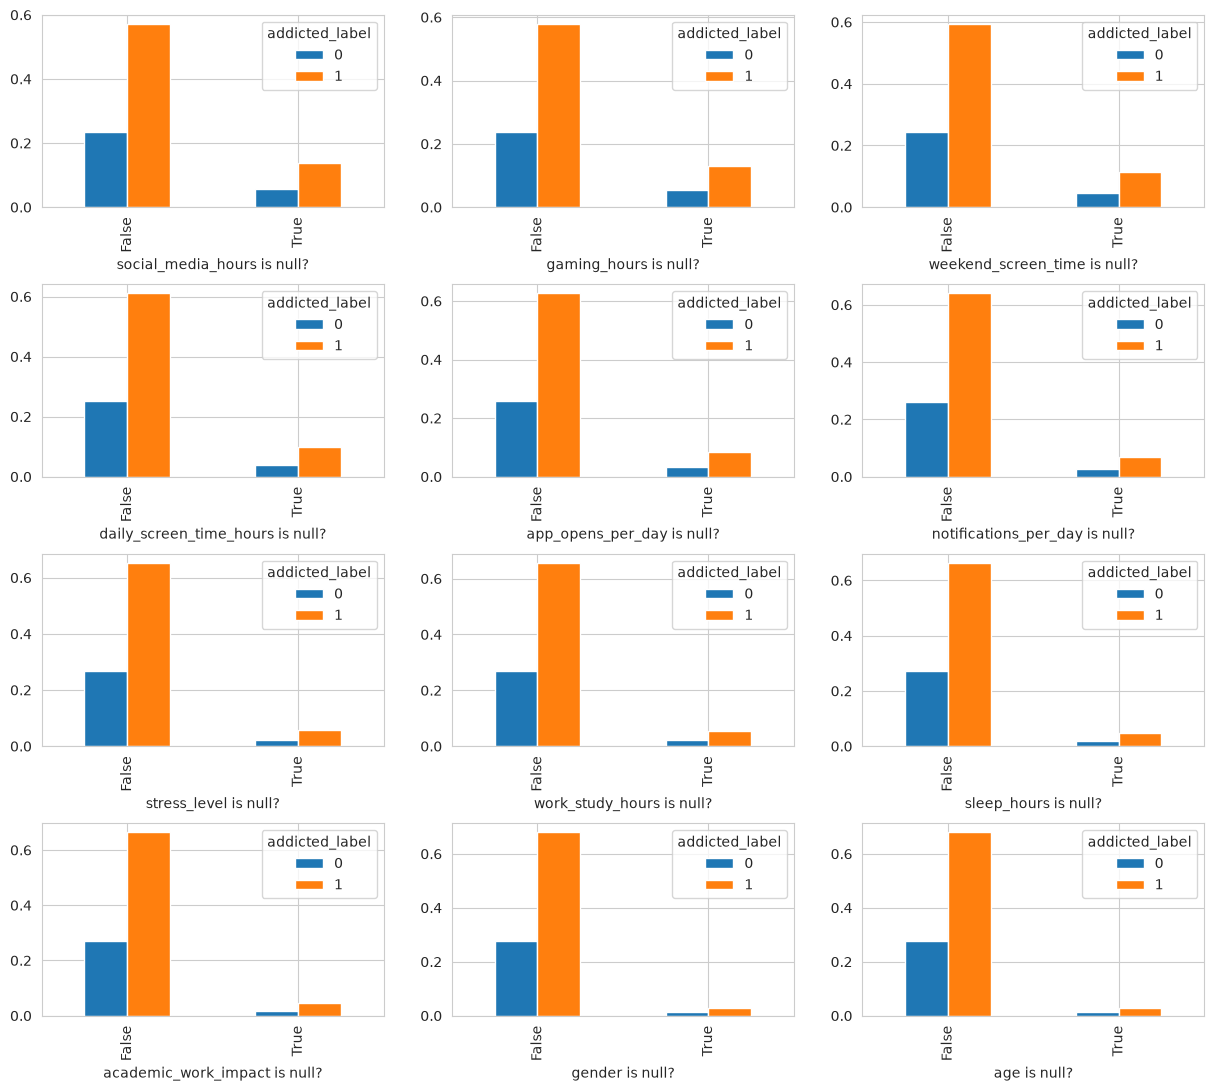

In [11]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 13))
fig.subplots_adjust(
    wspace=0.2,  # horizontal space
    hspace=0.4   # vertical space
)
axes = axes.flatten()
for i, col in enumerate(missing[missing>0].index):
    ct = pd.crosstab(train[col].isna(), train['addicted_label'], normalize=True)
    ct.plot(kind='bar', ax=axes[i])
    axes[i].set_xlabel(f'{col} is null?')
plt.show()

##### Note
Missing values are not affecting possibility of addicted_lebel(target).

## Features Distribution
### numeric columns

In [12]:
train.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.00,199581.18,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.62,5.15,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.64,2.72,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.47,1.32,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.46,0.93,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.37,1.26,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.80,1.23,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.89,65.92,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.64,48.09,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.48,2.86,0.51,7.28,9.58,11.75,17.56


#### Age and traget Reltionship

Note: age is contain null value so first will update then see distibution with target

<Axes: xlabel='age'>

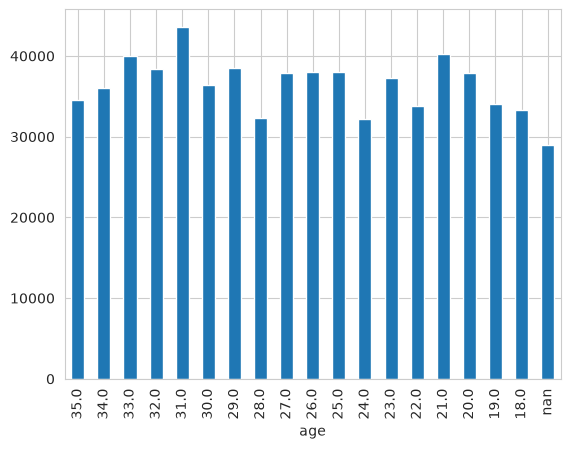

In [13]:
train['age'].value_counts(dropna=False).sort_index(ascending=False).plot(kind='bar')

Data is distributed uniformaly. if replace nan value from mean or medium it can create skeeness in age.

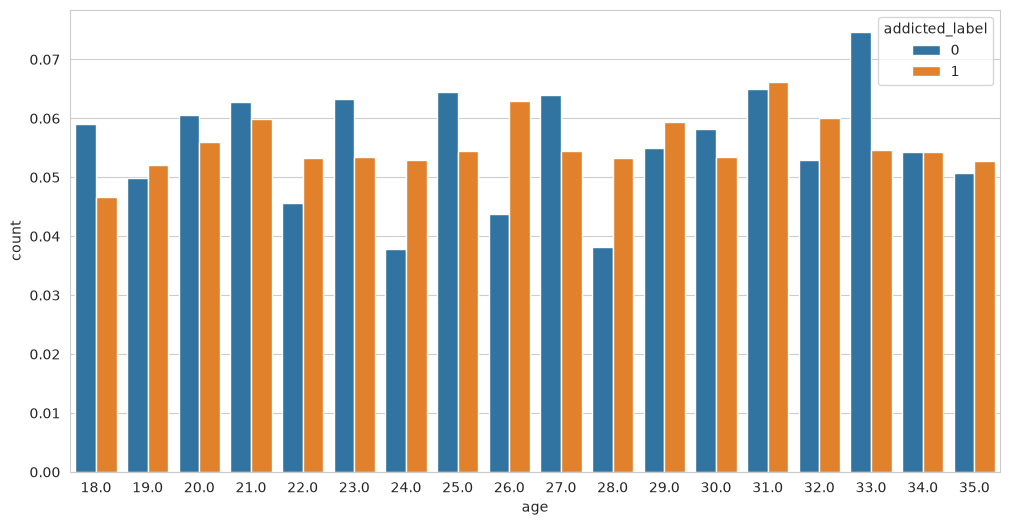

In [14]:

age_grou_by_addition = train.groupby('addicted_label')['age'].value_counts(normalize=True).reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(data=age_grou_by_addition, x='age', y='count', hue=target_lebel)
plt.show()

##### Note
- Their is not clear relation between age and target_label

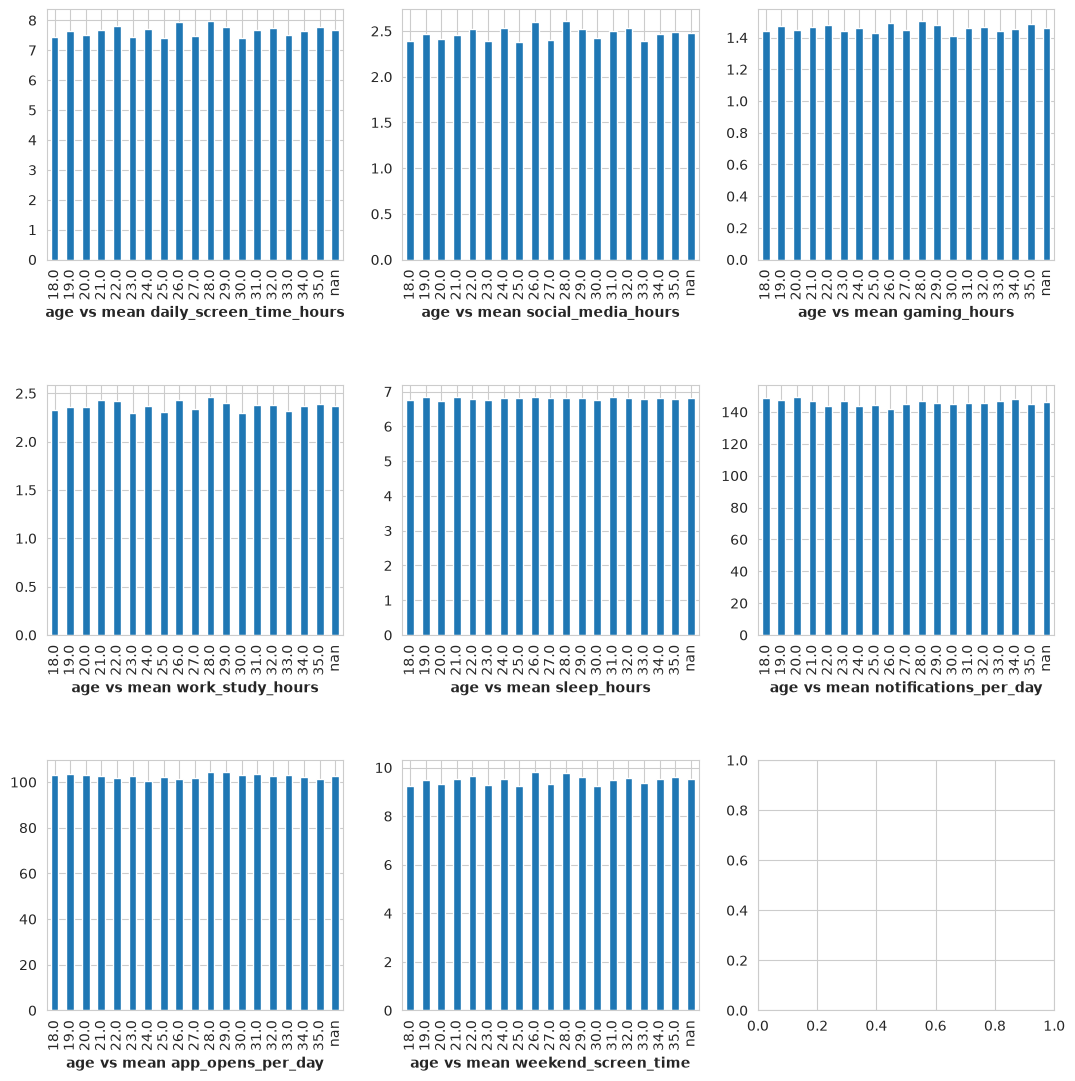

In [15]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(13, 13))
fig.subplots_adjust(
    wspace=0.2,
    hspace=0.5
)
axes = axes.flatten()

for i, ncol in enumerate(train.drop(['id', 'addicted_label', 'age'], axis=1).select_dtypes('number').columns):
    train.groupby('age', dropna=False)[ncol].mean().sort_index().plot(kind='bar', ax=axes[i])
    axes[i].set_xlabel(f"age vs mean {ncol}", fontdict=dict(weight='bold'))
plt.show()

In [16]:
df = train.copy()
df['age'] = df['age'].fillna(int(df['age'].mean()))
df.isna().sum()['age']

np.int64(0)

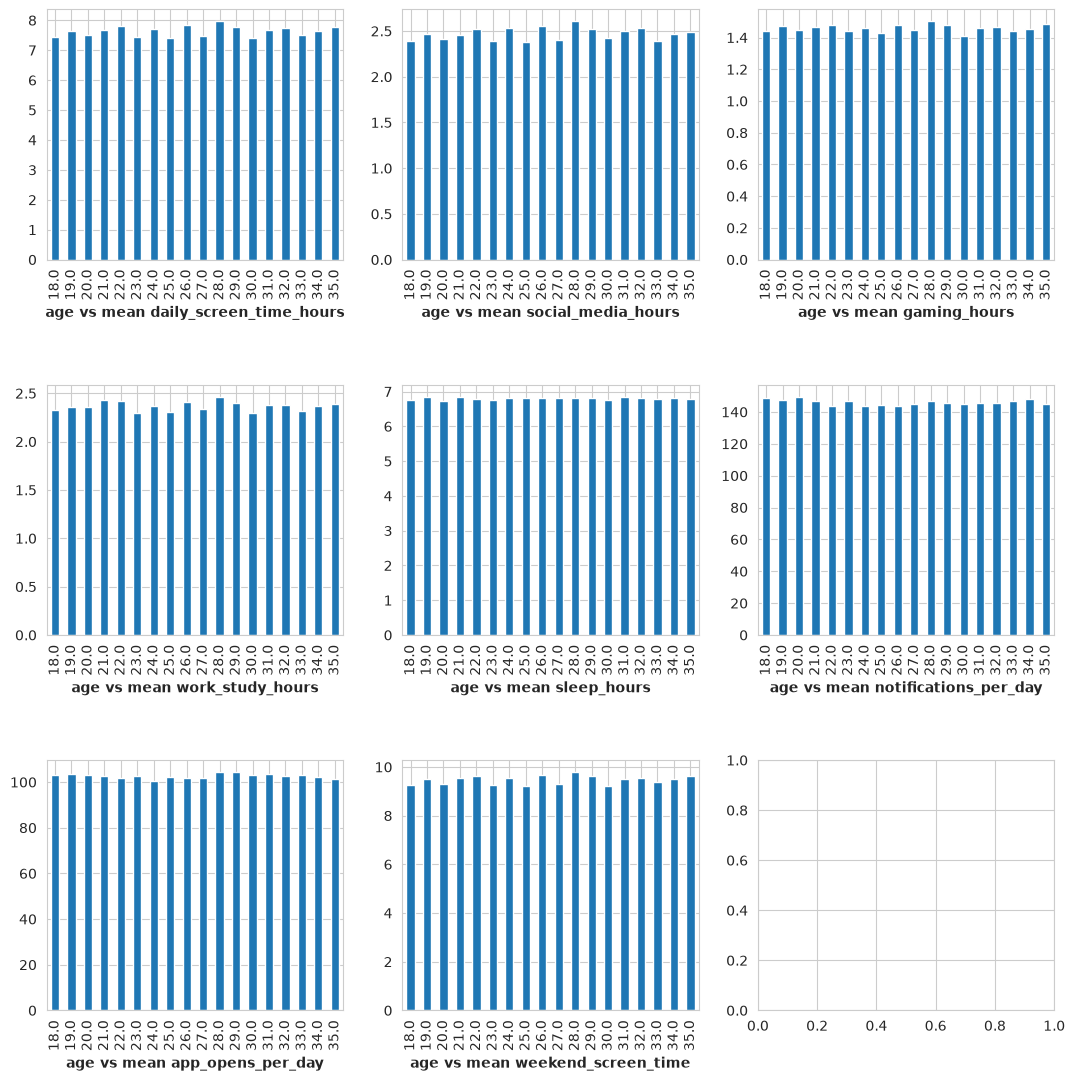

In [17]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(13, 13))
fig.subplots_adjust(
    wspace=0.2,
    hspace=0.5
)
axes = axes.flatten()

for i, ncol in enumerate(df.drop(['id', 'addicted_label', 'age'], axis=1).select_dtypes('number').columns):
    df.groupby('age', dropna=False)[ncol].mean().sort_index().plot(kind='bar', ax=axes[i])
    axes[i].set_xlabel(f"age vs mean {ncol}", fontdict=dict(weight='bold'))
plt.show()

##### Note
Numertics columns dribution very simmiler. So we leave with Nan value. Model like xgboost, and lightGBM well handel Nan numeric values.

#### Addition Label and other numeric column distibution

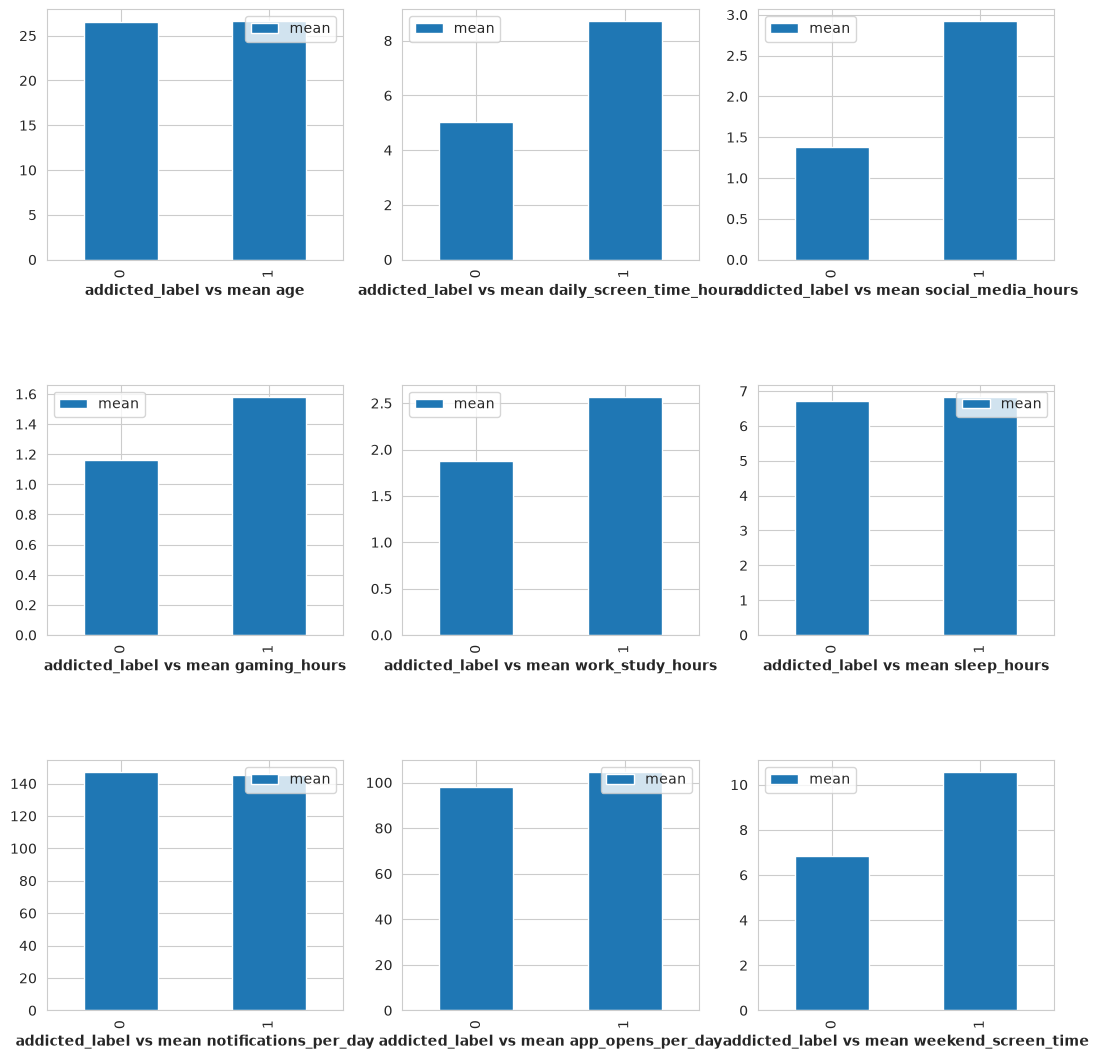

In [18]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(13, 13))
fig.subplots_adjust(
    wspace=0.2,
    hspace=0.5
)
axes = axes.flatten()
num_columns = df.drop(['id', 'addicted_label'], axis=1).select_dtypes('number').columns

for i, ncol in enumerate(num_columns):
    df.groupby(target_lebel)[ncol].mean().sort_index().reset_index(name='mean').plot(kind='bar', x=target_lebel, ax=axes[i])
    axes[i].set_xlabel(f"{target_lebel} vs mean {ncol}", fontdict=dict(weight='bold'))
plt.show()

##### Note
- Addication  directaly related to ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'weekend_screen_time']
- app_opens_per_day columns not affect Addication

## Category columns

In [19]:
cat_columns = train.select_dtypes('str').columns.to_list()
print(cat_columns)

['gender', 'stress_level', 'academic_work_impact']


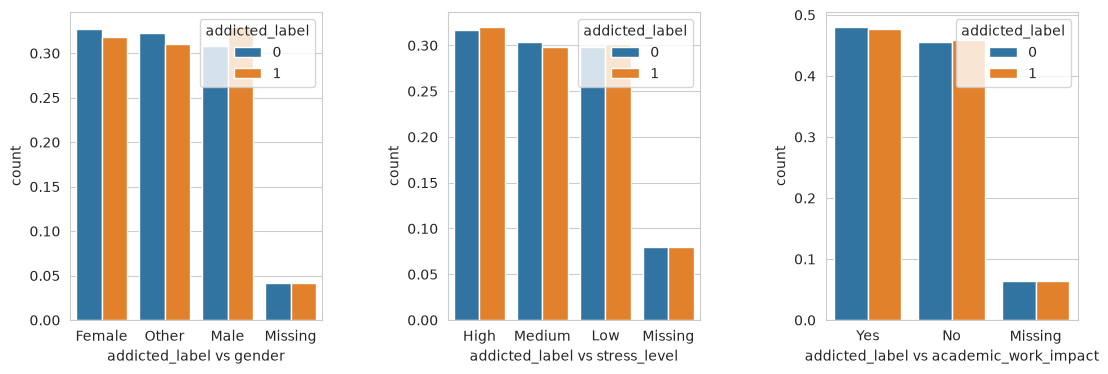

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
fig.subplots_adjust(
    wspace=0.5,
    hspace=0.0
)
axes = axes.flatten()

cdf = df[[target_lebel, *cat_columns]].fillna('Missing')

for i, col in enumerate(cat_columns):
    ndf = cdf.groupby(target_lebel)[col].value_counts(normalize=True).reset_index(name='count')
    sns.barplot(data=ndf, x=col, y='count', hue=target_lebel, ax=axes[i])
    axes[i].set_xlabel(f'{target_lebel} vs {col}')
plt.show()

##### Note
- Probiltity is equly distibuted for each category.
- Will replace missing value with 'Missing' cat.

## Cardinality analysis

In [21]:
train.nunique().sort_values(ascending=False)

id                         691369
weekend_screen_time          1437
daily_screen_time_hours      1389
social_media_hours            721
work_study_hours              600
sleep_hours                   451
gaming_hours                  401
notifications_per_day         231
app_opens_per_day             166
age                            18
gender                          3
stress_level                    3
academic_work_impact            2
addicted_label                  2
dtype: int64

## Duplicate analysis

In [22]:
train.duplicated().sum()

np.int64(0)

## Feature correlation

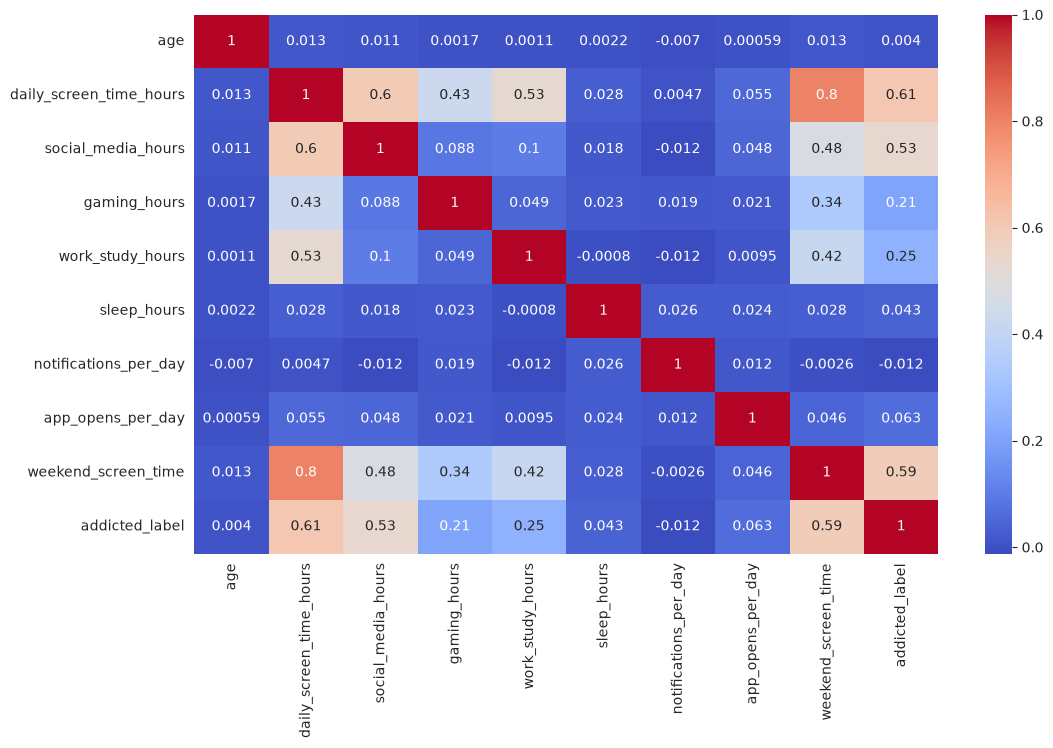

In [35]:
plt.figure(figsize=(12, 7))
sns.heatmap(data=train[[*num_columns, target_lebel]].corr(), annot=True, cmap='coolwarm')
plt.show()

##### Note
- Based on correlation matrix. Target more relate with diffrent screent, social media hour time.
- age, notification per day, sleep_hours,  are affecting addication

In [41]:
train[['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'weekend_screen_time', target_lebel]]

,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,weekend_screen_time,addicted_label
0,NaN,1.83,1.59,2.11,8.63,1
1,5.97,1.08,NaN,3.03,NaN,0
2,5.09,NaN,NaN,NaN,7.47,0
3,6.42,1.26,1.42,3.36,8.66,1
4,11.20,1.87,2.81,1.95,13.39,1
...,...,...,...,...,...,...
691364,10.78,3.25,1.57,1.65,12.89,1
691365,3.45,1.86,0.89,0.30,8.47,1
691366,NaN,NaN,NaN,2.06,7.79,1
691367,11.78,3.69,0.23,1.35,7.71,1


In [49]:
train['gaming_social_media'] = train[['social_media_hours', 'gaming_hours']].sum(axis=1)
train['totla_screen_time'] = train[['social_media_hours', 'gaming_hours', 'work_study_hours']].sum(axis=1)

In [59]:
train.groupby([target_lebel, 'gender'], dropna=False)[['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'weekend_screen_time', 'gaming_social_media', 'totla_screen_time']].mean().T

addicted_label                  0                                        1  \
gender                     Female      Male     Other       NaN     Female   
daily_screen_time_hours  5.045836  5.030549  5.052531  5.036807   8.690527   
social_media_hours       1.370453  1.377149  1.379828  1.385264   2.915820   
gaming_hours             1.155617  1.158420  1.165292  1.157229   1.574745   
work_study_hours         1.886203  1.858893  1.873014  1.863527   2.569749   
weekend_screen_time      6.848261  6.865981  6.837002  6.818247  10.535074   
gaming_social_media      2.057290  2.059209  2.068975  1.950598   3.649073   
totla_screen_time        3.806831  3.783436  3.802455  3.630749   6.029691   

addicted_label                                            
gender                        Male      Other        NaN  
daily_screen_time_hours   8.728452   8.697400   8.724201  
social_media_hours        2.928064   2.914293   2.918501  
gaming_hours              1.588797   1.582732   1.580841  
work_study_hours          2.562653   2.573663   2.592784  
weekend_screen_time      10.588354  10.552815  10.548495  
gaming_social_media       3.665378   3.649427   3.424395  
totla_screen_time         6.039245   6.032842   5.769353

In [62]:
print(train.columns.to_list())

['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'addicted_label', 'gaming+social_media', 'totla_screen_time', 'gaming_social_media']


## Conclution
- Will consider only ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'weekend_screen_time', 'totla_screen_time', 'gaming_social_media'] thse columns to use train model other colums are affecting addition.
- will use Nan value for nums coluns
- use stander scaler
- Use xgboost, lightGBM and Catboost.
- findout optim model paramers from optuna
- use 5 CV

## Final Modeling and Validation Plan

The competition metric is ROC AUC, so optimize probability ranking rather than accuracy or a classification threshold.

### 1. Prepare the data
- Apply one identical preprocessing function to train and test.
- Exclude `id` from model features.
- Keep numeric missing values as `NaN` for LightGBM/XGBoost.
- Replace missing categorical values with `Missing`.
- Verify that train and test columns and category levels match.

### 2. Features
Use all 12 original predictors. Do not remove features solely because their univariate correlation is weak; tree models can use nonlinear effects and interactions.

Add and validate the following feature groups:
- Missing indicator for every column and total missing-value count
- Social-media plus gaming hours
- Daily/weekend screen-time difference and ratio
- Total usage hours
- Squared or binned versions of major usage variables
- Interactions among screen time, sleep, stress, and academic impact

Keep an engineered feature only if it improves out-of-fold (OOF) ROC AUC.

### 3. Validation
- Use stratified 5-fold cross-validation with the same folds for every model.
- Record mean ROC AUC, fold standard deviation, OOF predictions, and the train/validation gap.
- Perform all imputation, encoding, feature selection, and tuning inside each training fold to prevent leakage.

### 4. Models
Train LightGBM, CatBoost, and XGBoost as separate baselines. Use early stopping and optimize ROC AUC. Standard scaling is not required for these tree models.

After establishing baselines, use Optuna to tune learning rate, tree complexity, minimum child samples, feature/row sampling, regularization, and boosting rounds. Avoid an excessively large search that overfits one validation split.

### 5. Blending
- Generate OOF predictions for every strong model.
- Test weighted probability averaging and rank averaging.
- Optimize blend weights using OOF predictions only.
- Prefer the blend with the best mean OOF AUC and stable fold performance.

### 6. Final training and submission
- Retrain the selected models on the complete training set.
- Predict probabilities for the test set and apply the selected blend.
- Create `id,addicted_label` in the same row order as `sample_submission.csv`.
- Submit probabilities, not hard 0/1 labels.

### Success criteria
Prioritize mean OOF ROC AUC, then low fold variance, blend improvement, and finally the public leaderboard result. First establish a local score above 0.96, then iterate toward the top leaderboard range through leakage-safe feature engineering and blending.